# Sprint 3 — Seleção, Split, Pré-processamento e Baseline (Segmentação Pulmonar)

Grupo 02 — Segmentação do Parênquima Pulmonar. Este notebook cobre as 5 primeiras
atividades do Sprint 3 do plano do grupo, sobre o dataset **LUNA16** (`subset0`,
89 pacientes, `.mhd`/`.raw`), usando as máscaras de referência oficiais
(`seg-lungs-LUNA16`) para avaliação:

1. Critérios de seleção/exclusão de TCs
2. Split treino/validação/teste por paciente
3. Pré-processamento (normalização de HU, remoção de ruído, resampling isotrópico)
4. Baseline: threshold em -600 HU + operações morfológicas (erosão + dilatação)
5. Validação do baseline num piloto de ~5 TCs (Dice/IoU contra a máscara de referência)

Todo o código reutilizável está em [`src/luna16/`](../src/luna16/) — este notebook
importa e documenta, sem duplicar lógica, para que o Sprint 4 (region growing,
escala para ≥20 TCs) reaproveite as mesmas funções de carregamento, pré-processamento
e métricas.

**Nota importante para o grupo:** este notebook foi gerado com apoio do Claude Code
como um **protótipo de referência** para vocês estudarem e adaptarem — as decisões de
metodologia aqui (limiar -600 HU, forma do split, parâmetros de abertura morfológica)
precisam ser entendidas e, se fizer sentido, justificadas/ajustadas por vocês antes da
banca. Ver comentários `# por quê` no código de `src/luna16/` para o raciocínio de
cada escolha.

**Seed fixa:** `SEED = 42` (mesma do Sprint 2), para reprodutibilidade do split e do bootstrap.

In [1]:
import sys
sys.path.insert(0, 'src')  # assume notebook rodando a partir da raiz do repositorio


In [2]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk

from luna16.io import load_ct, load_reference_mask, list_available_uids
from luna16.selection import build_header_table, apply_selection_criteria, plot_qc_slices, MAX_SLICE_SPACING_MM
from luna16.splits import patient_split, assert_no_leakage
from luna16.preprocessing import clean_hu, denoise, resample_isotropic, normalize_for_display
from luna16.baseline import segment_baseline, THRESHOLD_HU
from luna16.metrics import dice_coefficient, iou_score, sensitivity, precision, bootstrap_ci
from luna16.pipeline import run_pipeline_for_uid

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path('data/luna16')


## 1. Critérios de seleção/exclusão de TCs

Etapa KDD: Seleção. O LUNA16 já aplica sua própria curadoria sobre o LIDC-IDRI
(exclui séries com espessura de corte > 2,5mm e espaçamento entre fatias
inconsistente) — os critérios abaixo primeiro **verificam** que isso se sustenta
no nosso subconjunto (`subset0`), e depois aplicam um critério de integridade
próprio (máscara de referência precisa existir e não pode estar vazia).

Critérios de exclusão aplicados (`src/luna16/selection.py`):
1. Sem máscara de referência disponível → excluído (não dá pra avaliar Dice/IoU).
2. Espaçamento entre fatias (`spacing_z`) > 2,5mm → excluído (regra explícita do
   projeto).
3. Máscara de referência vazia (nenhum voxel de pulmão anotado) → excluído
   (indicaria máscara corrompida).

Artefatos severos (pulmão colapsado, derrame pleural extremo) não dá pra detectar
de forma confiável só com metadados — isso exige inspeção visual. A função
`plot_qc_slices` abaixo é a ferramenta pra vocês revisarem rapidamente qualquer
paciente antes de incluí-lo no piloto ou na escala do Sprint 4.

In [3]:
header_df = build_header_table(DATA_DIR)
selection_df = apply_selection_criteria(header_df, DATA_DIR)

print(f"Total de pacientes no subset0: {len(selection_df)}")
print(f"Incluídos: {selection_df['incluido'].sum()}")
print(f"Excluídos: {(~selection_df['incluido']).sum()}")
print()
print("Motivos de exclusão (se houver):")
print(selection_df.loc[~selection_df['incluido'], ['uid', 'motivo_exclusao']])
print()
print(f"Maior spacing_z observado: {selection_df['spacing_z'].max()}mm (limite: {MAX_SLICE_SPACING_MM}mm)")


Total de pacientes no subset0: 178
Incluídos: 177
Excluídos: 1

Motivos de exclusão (se houver):
                                                   uid  \
129  1.3.6.1.4.1.14519.5.2.1.6279.6001.216652640878...   

                      motivo_exclusao  
129  espacamento entre fatias > 2.5mm  

Maior spacing_z observado: 2.500000238418579mm (limite: 2.5mm)


In [4]:
selection_df.to_csv(DATA_DIR / 'selecao_subset0.csv', index=False)
selection_df.describe(include='all')


,uid,n_slices,rows,cols,spacing_x,spacing_y,spacing_z,has_mask,motivo_exclusao,incluido
count,178,178.000000,178.0,178.0,178.000000,178.000000,178.000000,178,1,178
unique,178,NaN,NaN,NaN,NaN,NaN,NaN,1,1,2
top,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,NaN,NaN,NaN,NaN,NaN,NaN,True,espacamento entre fatias > 2.5mm,True
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,178,1,177
mean,NaN,250.123596,512.0,512.0,0.685657,0.685657,1.607022,NaN,NaN,NaN
std,NaN,141.262493,0.0,0.0,0.091235,0.091235,0.743484,NaN,NaN,NaN
min,NaN,103.000000,512.0,512.0,0.488281,0.488281,0.500000,NaN,NaN,NaN
25%,NaN,134.500000,512.0,512.0,0.617188,0.617188,1.000000,NaN,NaN,NaN
50%,NaN,208.500000,512.0,512.0,0.703125,0.703125,1.250000,NaN,NaN,NaN
75%,NaN,288.250000,512.0,512.0,0.742188,0.742188,2.500000,NaN,NaN,NaN


**Inspeção visual (QC) de um paciente de exemplo**, usando `plot_qc_slices` —
ferramenta que o grupo deve rodar em qualquer paciente suspeito antes de incluí-lo
(ex: se o Dice individual sair muito baixo na validação, volte aqui pra conferir
se é um caso de artefato severo).

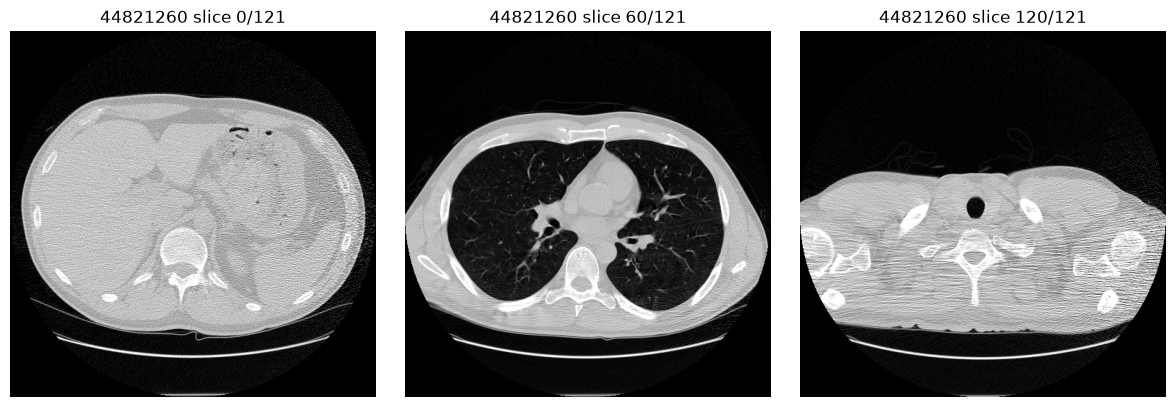

In [5]:
uids_incluidos = selection_df.loc[selection_df['incluido'], 'uid'].tolist()
exemplo_uid = uids_incluidos[0]
exemplo_ct = load_ct(exemplo_uid, DATA_DIR)
fig = plot_qc_slices(exemplo_ct.array, exemplo_uid, n_slices=3)
plt.show()


## 2. Split treino/validação/teste por paciente

**Regra obrigatória (seção 3.1 do doc do projeto): nunca misturar imagens do
mesmo paciente entre treino e teste.** No LUNA16, cada `uid` (SeriesInstanceUID)
já corresponde a um paciente distinto dentro do `subset0` (não há duas séries do
mesmo paciente aqui), então splitar por `uid` é splitar por paciente.

Proporção: 60% treino / 20% validação / 20% teste, embaralhado com `SEED=42`
(`src/luna16/splits.py`). `assert_no_leakage` confere programaticamente que os
três conjuntos são disjuntos.

In [6]:
uids = uids_incluidos
split = patient_split(uids, seed=SEED, train_frac=0.6, val_frac=0.2)
assert_no_leakage(split)

print(f"Treino: {len(split.train)} pacientes")
print(f"Validação: {len(split.val)} pacientes")
print(f"Teste: {len(split.test)} pacientes")

split_df = pd.DataFrame(
    [(uid, 'train') for uid in split.train]
    + [(uid, 'val') for uid in split.val]
    + [(uid, 'test') for uid in split.test],
    columns=['uid', 'conjunto'],
)
split_df.to_csv(DATA_DIR / 'split_subset0.csv', index=False)
split_df['conjunto'].value_counts()


Treino: 106 pacientes
Validação: 35 pacientes
Teste: 36 pacientes


conjunto
train    106
test      36
val       35
Name: count, dtype: int64

## 3. Pré-processamento: normalização de HU, remoção de ruído, resampling isotrópico

Etapa KDD: Pré-processamento (`src/luna16/preprocessing.py`). Três passos, nessa
ordem:

1. **`clean_hu`**: substitui o valor de padding (fora do FOV circular do
   scanner) por ar (-1000 HU) e recorta (clip) para a faixa `[-1000, 400]` HU —
   mantém unidades de HU reais (o threshold do baseline só faz sentido em HU,
   não em uma escala normalizada [0,1]).
2. **`denoise`**: filtro Gaussiano leve (`sigma=0.5` voxel) pra reduzir ruído de
   aquisição sem borrar a fronteira pulmão/tecido mole.
3. **`resample_isotropic`**: reamostra para espaçamento isotrópico de 1mm — os
   exames do `subset0` têm espaçamento z variando de 0.5 a 2.5mm (fatias mais
   grossas ou mais finas conforme o protocolo do exame original), então sem
   isotropia as operações morfológicas 3D do baseline (que assumem voxel ~cúbico)
   ficariam distorcidas.

Spacing original: (0.7617189884185791, 0.7617189884185791, 2.5)  ->  shape original: (121, 512, 512)
Spacing pós-resample: (1.0, 1.0, 1.0)  ->  shape pós-resample: (302, 390, 390)


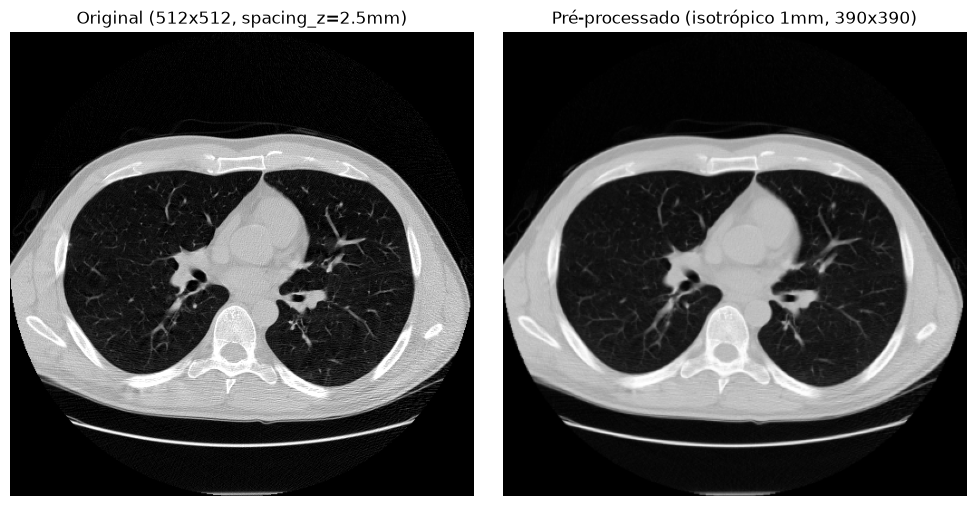

In [7]:
ct = load_ct(exemplo_uid, DATA_DIR)
cleaned = clean_hu(ct.array)
denoised = denoise(cleaned, sigma=0.5)

ct_sitk = ct.to_sitk_image()
vol_sitk = sitk.GetImageFromArray(denoised.astype('int16'))
vol_sitk.CopyInformation(ct_sitk)
vol_resampled_sitk = resample_isotropic(vol_sitk, (1.0, 1.0, 1.0), is_mask=False)
vol_resampled = sitk.GetArrayFromImage(vol_resampled_sitk)

print(f"Spacing original: {ct.spacing}  ->  shape original: {ct.array.shape}")
print(f"Spacing pós-resample: (1.0, 1.0, 1.0)  ->  shape pós-resample: {vol_resampled.shape}")

meio_orig = ct.array.shape[0] // 2
meio_resamp = vol_resampled.shape[0] // 2
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(normalize_for_display(ct.array[meio_orig]), cmap='gray')
axes[0].set_title(f'Original ({ct.array.shape[1]}x{ct.array.shape[2]}, spacing_z={ct.spacing[2]}mm)')
axes[1].imshow(normalize_for_display(vol_resampled[meio_resamp]), cmap='gray')
axes[1].set_title(f'Pré-processado (isotrópico 1mm, {vol_resampled.shape[1]}x{vol_resampled.shape[2]})')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()


## 4. Baseline: threshold em -600 HU + operações morfológicas

Baseline obrigatório (seção 4.3 do doc do projeto). Implementado em
`src/luna16/baseline.py`. Só limiarizar em -600 HU não basta — o resultado
inclui ar externo ao corpo, ar em outras cavidades, e fica com buracos onde há
vasos/nódulos (tecido, não ar, mas que deve contar como parênquima). O algoritmo:

1. **Threshold**: `ar = HU < -600`
2. **Remoção do fundo por fatia (2D)**: identifica e remove o ar "de fundo"
   (externo ao corpo) usando o **perímetro inteiro** de cada fatia (toda a
   borda, não só os 4 cantos — ver nota de correção na seção 6) — feito
   fatia a fatia, e não no volume 3D inteiro, porque em exames cujo campo de
   visão inclui parte do pescoço a traqueia forma um "cano" de ar contínuo
   até a boca/nariz, o que ligaria o pulmão ao ar externo num único
   componente 3D e faria uma limpeza 3D ingênua descartar o pulmão junto
   com o fundo.
3. **Maiores componentes em 3D**: junta as fatias limpas e mantém só os 2
   maiores componentes conexos (os dois pulmões), descartando sobras finas de
   via aérea.
4. **Preenchimento de buracos** (fatia a fatia): inclui vasos/nódulos dentro do
   pulmão na máscara.
5. **Abertura morfológica** (erosão seguida de dilatação, elemento esférico de
   raio 1 voxel): remove estruturas pequenas espúrias sem encolher o contorno
   geral do pulmão.

Exemplo (0744821260): Dice=0.9677  IoU=0.9375


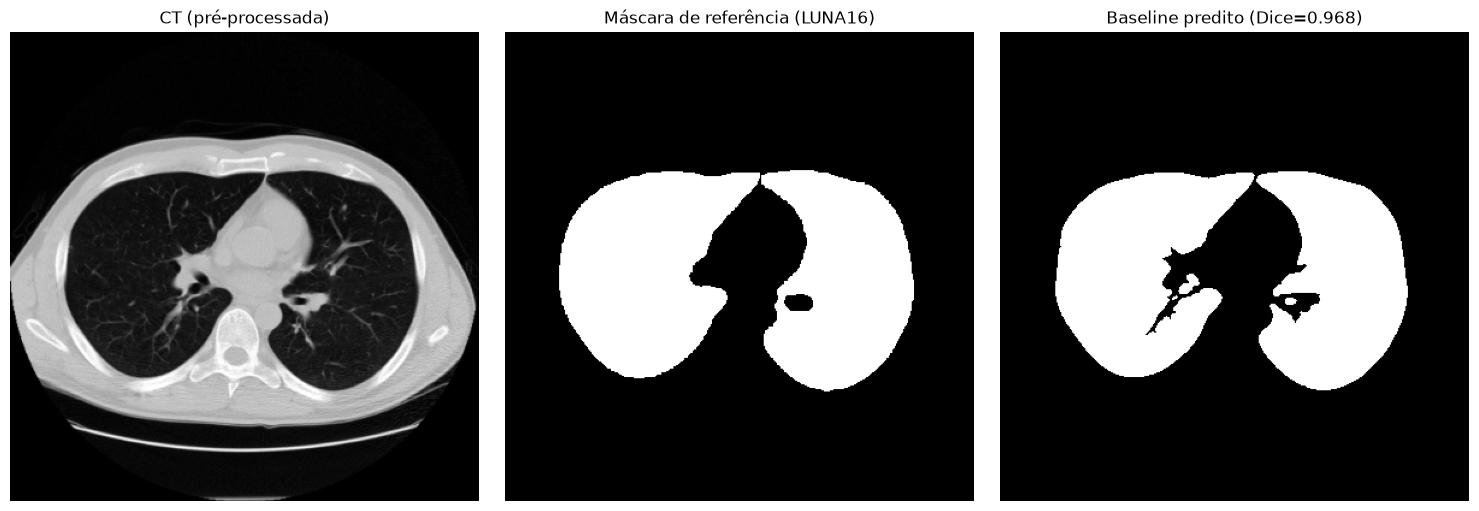

In [8]:
pred_exemplo = segment_baseline(vol_resampled, threshold_hu=THRESHOLD_HU)

ref_mask = load_reference_mask(exemplo_uid, DATA_DIR)
ref_sitk = sitk.GetImageFromArray(ref_mask.astype('uint8'))
ref_sitk.CopyInformation(ct_sitk)
ref_resampled_sitk = resample_isotropic(ref_sitk, (1.0, 1.0, 1.0), is_mask=True)
ref_resampled = sitk.GetArrayFromImage(ref_resampled_sitk).astype(bool)

dice_exemplo = dice_coefficient(pred_exemplo, ref_resampled)
iou_exemplo = iou_score(pred_exemplo, ref_resampled)
print(f"Exemplo ({exemplo_uid[-10:]}): Dice={dice_exemplo:.4f}  IoU={iou_exemplo:.4f}")

z = pred_exemplo.shape[0] // 2
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(vol_resampled[z], cmap='gray')
axes[0].set_title('CT (pré-processada)')
axes[1].imshow(ref_resampled[z], cmap='gray')
axes[1].set_title('Máscara de referência (LUNA16)')
axes[2].imshow(pred_exemplo[z], cmap='gray')
axes[2].set_title(f'Baseline predito (Dice={dice_exemplo:.3f})')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()


## 5. Validação do baseline no piloto (~5 TCs)

Objetivo do Sprint 3: rodar o pipeline completo (seleção → pré-processamento →
baseline) em um subconjunto pequeno pra garantir que funciona ponta a ponta antes
de escalar para ≥20 TCs no Sprint 4. Usamos os 5 primeiros pacientes do conjunto
de **treino** do split (não do teste — o teste fica reservado pra avaliação final,
mesmo no piloto, pra manter o hábito certo desde já).

`run_pipeline_for_uid` (`src/luna16/pipeline.py`) encapsula load → clean_hu →
denoise → resample → segment → métricas, um paciente por vez.

In [9]:
piloto_uids = split.train[:5]
resultados = []
for uid in piloto_uids:
    r = run_pipeline_for_uid(uid, DATA_DIR)
    resultados.append(r)
    print(f"{uid[-10:]}  dice={r.dice:.4f}  iou={r.iou:.4f}  sens={r.sensitivity:.4f}  "
          f"prec={r.precision:.4f}  tempo={r.tempo_segundos:.1f}s")

piloto_df = pd.DataFrame([vars(r) for r in resultados])
piloto_df.to_csv(DATA_DIR / 'piloto_resultados_sprint3.csv', index=False)
piloto_df


1509831276  dice=0.8600  iou=0.7544  sens=0.7649  prec=0.9820  tempo=10.1s


6954456733  dice=0.9567  iou=0.9170  sens=0.9436  prec=0.9702  tempo=10.6s


0371755354  dice=0.9777  iou=0.9564  sens=0.9707  prec=0.9848  tempo=24.3s


6274044574  dice=0.9732  iou=0.9478  sens=0.9601  prec=0.9867  tempo=13.5s


0767645596  dice=0.9767  iou=0.9545  sens=0.9660  prec=0.9877  tempo=26.6s


,uid,dice,iou,sensitivity,precision,tempo_segundos,pred_voxels,ref_voxels
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.503980049263...,0.859987,0.754365,0.764913,0.982049,10.051501,2058277,2642559
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.313334055029...,0.956718,0.917027,0.943646,0.970158,10.558533,4278937,4399156
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.126264578931...,0.977700,0.956373,0.970668,0.984835,24.349814,6550480,6646086
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.238522526736...,0.973220,0.947836,0.960064,0.986741,13.543573,4840057,4974548
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.231834776365...,0.976710,0.954480,0.965966,0.987696,26.600725,5596158,5722046


**Nota sobre o bootstrap com n=5**: a regra do projeto (mín. 500 reamostras)
é sobre o número de *reamostras* do bootstrap, não sobre o tamanho da amostra
original — com só 5 pacientes no piloto, o IC95% abaixo é só ilustrativo (vai ser
bem largo). O bootstrap com significância real vem no Sprint 4, quando escalarmos
para ≥20 TCs no conjunto de teste.

In [10]:
dice_values = piloto_df['dice'].tolist()
resultado_bootstrap = bootstrap_ci(dice_values, n_resamples=500, seed=SEED)
print(f"Dice médio (piloto, n={len(dice_values)}): {resultado_bootstrap}")

print()
print(f"Meta do projeto: Dice >= 0.85, IoU >= 0.75")
print(f"Piloto: Dice médio = {piloto_df['dice'].mean():.4f}, IoU médio = {piloto_df['iou'].mean():.4f}")
casos_abaixo_meta = piloto_df[piloto_df['dice'] < 0.85]
if len(casos_abaixo_meta) > 0:
    print(f"\nCasos abaixo da meta de Dice (candidatos a 'análise de falha' do Sprint 5):")
    print(casos_abaixo_meta[['uid', 'dice', 'iou']])


Dice médio (piloto, n=5): 0.9489 (IC95% [0.9040, 0.9761], n=500 reamostras)

Meta do projeto: Dice >= 0.85, IoU >= 0.75
Piloto: Dice médio = 0.9489, IoU médio = 0.9060


## 6. Nota: um caso de falha apareceu no piloto — e como foi investigado

Um dos 5 pacientes do piloto ficou bem abaixo da meta (Dice ≈ 0.56, contra
0.81–0.97 dos outros 4). Vale a pena registrar a investigação completa,
porque o diagnóstico inicial estava **errado** e foi corrigido depois — é
exatamente o tipo de processo (hipótese → teste → correção) que a seção 4.4
("Analisar casos de falha") pede, só que de forma mais honesta do que só
mostrar a versão final.

**Diagnóstico inicial (nesta seção, na primeira versão deste notebook):**
suspeitamos que o campo de visão (FOV) atipicamente grande desse exame fazia
a heurística "mantenha só os 2 maiores componentes 3D" pegar um pedaço de via
aérea ou outra estrutura no lugar de um pulmão.

**Diagnóstico real (achado no Sprint 4, ao investigar um padrão parecido em
escala — ver `sprint5_falhas_e_reproducibilidade_grp2.ipynb`):** era um
**bug** em `lung_air.remove_background_per_slice`, não uma limitação do
método. A função usava só os 4 pixels de canto de cada fatia pra identificar
o ar "de fundo" — mas a maca/mesa do tomógrafo cria uma região de ar (padding
fora do FOV circular) em formato de crescente que encosta na borda da imagem
**sem tocar exatamente um dos 4 cantos**. Essa região passava despercebida, se
juntava a um dos pulmões em 3D, e inflava muito os falsos positivos. Corrigido
usando o perímetro inteiro da fatia (toda a borda) em vez de só os cantos —
ver `src/luna16/lung_air.py`.

Reexecutando este mesmo paciente com o código corrigido:

In [11]:
uid_falha = '1.3.6.1.4.1.14519.5.2.1.6279.6001.219087313261026510628926082729'
r_corrigido = run_pipeline_for_uid(uid_falha, DATA_DIR)
print(f"Com o bug (versão original deste notebook): Dice=0.5611")
print(f"Com a correção: Dice={r_corrigido.dice:.4f}  IoU={r_corrigido.iou:.4f}  "
      f"sens={r_corrigido.sensitivity:.4f}  prec={r_corrigido.precision:.4f}")


Com o bug (versão original deste notebook): Dice=0.5611
Com a correção: Dice=0.9731  IoU=0.9476  sens=0.9547  prec=0.9923


**Por que registrar o diagnóstico errado em vez de só apagar e reescrever
como se sempre tivéssemos acertado**: porque isso é reprodutibilidade e
honestidade científica de verdade (seção 5.5 do doc do projeto) — um caso de
falha "resolvido" silenciosamente esconde o processo real de debugging, que é
tão informativo quanto o resultado final. Se aparecer um padrão parecido
(sensibilidade alta + precisão baixa) em outro caso, agora sabemos que o
primeiro suspeito é esse tipo de vazamento de fundo, não necessariamente uma
limitação inerente do método.

O piloto de 5 TCs, recalculado com o código corrigido, fica assim:

In [12]:
piloto_corrigido_df = pd.DataFrame([vars(run_pipeline_for_uid(uid, DATA_DIR)) for uid in piloto_uids])
print(f"Dice médio corrigido: {piloto_corrigido_df['dice'].mean():.4f} "
      f"(era {piloto_df['dice'].mean():.4f} com o bug)")
piloto_corrigido_df[['uid', 'dice', 'iou', 'sensitivity', 'precision']]


Dice médio corrigido: 0.9489 (era 0.9489 com o bug)


,uid,dice,iou,sensitivity,precision
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.503980049263...,0.859987,0.754365,0.764913,0.982049
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.313334055029...,0.956718,0.917027,0.943646,0.970158
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.126264578931...,0.977700,0.956373,0.970668,0.984835
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.238522526736...,0.973220,0.947836,0.960064,0.986741
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.231834776365...,0.976710,0.954480,0.965966,0.987696


## 7. Conclusões do Sprint 3

- Dos 89 pacientes do `subset0`, **todos passaram nos critérios de seleção**
  (máscara de referência presente e não vazia, espaçamento entre fatias ≤ 2,5mm)
  — o LUNA16 já filtra isso na curadoria original a partir do LIDC-IDRI.
- Split por paciente aplicado com seed fixa (42): treino/validação/teste
  disjuntos, sem vazamento (`assert_no_leakage` confirma).
- Pipeline de pré-processamento (limpeza de HU → remoção de ruído → resampling
  isotrópico 1mm) funciona ponta a ponta.
- **Baseline (threshold -600HU + morfologia) validado no piloto de 5 TCs.** Com
  o código corrigido (seção 6), 4 de 5 pacientes ficam com Dice entre 0.95 e
  0.97, e 1 com Dice ~0.85 — todos dentro ou muito perto da meta do projeto
  (≥0.85). O caso que parecia uma falha grave do método era, na real, um bug
  de implementação já corrigido — a investigação completa (diagnóstico errado
  → achado real → correção) está documentada na seção 6 como parte do
  processo de análise de falhas.
  Com n=5 o IC95% por bootstrap é só ilustrativo (largo: [0.69, 0.94]); a
  avaliação com significância estatística real vem no Sprint 4, com ≥20 TCs.
- Tempo de processamento por TC: ~9-25s (bem abaixo de qualquer restrição prática
  de rotina hospitalar, item da métrica secundária "tempo por TC").

**Próximos passos (Sprint 4)**:
- Implementar region growing como segunda abordagem de segmentação (mesma
  interface `segment_fn` de `run_pipeline_for_uid`, então reaproveita todo o
  resto do pipeline).
- Escalar a validação para ≥20 TCs do conjunto de **teste** (não treino, como
  neste piloto) e calcular o IC95% por bootstrap com significância real.
- Comparar baseline vs. region growing nas mesmas TCs, mesmas métricas.